# **Herramientas básicas para el Análisis de Datos**
# **Trabajo Final Integrador**
# Analisis de Datos de Dengue en Argentina
##### Comisión 999201624
##### Abril 2026
### Mariana Barone

## 1. **Búsqueda y selección del dataset**

Me interesaba trabajar con datos de Argentina, así que busqué en el [Portal de Datos Argentina](https://datos.gob.ar/dataset). Seleccioné la base de datos de [Vigilancia de Dengue y Zika de las semanas 1 a 52 de 2024 y 2025](https://datos.salud.gob.ar/dataset/vigilancia-de-dengue-y-zika/archivo/e57edd84-096d-4348-9137-2f5dae9c8f55) y el registro de [Vigilancia de Dengue y Zika de las semanas 1 a 52 de 2025 y 1 a 12 de 2026](https://datos.salud.gob.ar/dataset/vigilancia-de-dengue-y-zika/archivo/33e12e9f-1d14-4bc7-b34c-a1f88ab7b990). De esta manera tenemos el registro de los casos a lo largo de más de dos años.


Estos datos son casos confirmados que provienen del Registro del [Sistema Nacional de Vigilancia de la Salud 2.0](https://sisa.msal.gov.ar/sisadoc/docs/050216/snvs_intro.jsp).

*Los datos epidemiológicos son importantes para establecer grupos de mayor riesgo y mejores estrategias preventivas de acción, particularmente en enfermedades transmitidas por vectores como el mosquito, que tiene una prevalencia acotada en los meses de mayor temperatura.*

### Preguntas a resolver
1) **¿Cómo fue la evolución temporal de casos totales de dengue en Argentina a lo largo de las semanas epidemiológicas de los años 2024 a 2026?**

2) **¿Qué grupo/s de edad son potencialmente más propensos al contagio, independientemente de la información georgráfica, según los años registrados?**

3) **¿Cuáles provincias argentinas tuvieron una mayor cantidad de casos en los años registrados?**
    
    > Subpregunta: **¿Cómo es la distribución de casos a lo largo de los departamentos de la provincia con mayor cantidad de casos?**


#### *La información que se obtiene al responder estas preguntas es crucial para la planificación de recursos y tiempos a invertir en la prevención de la enfermedad.*

## 2. **Ingesta y limpieza**
En este punto cargamos las bases de datos seleccionadas, las combinamos, elegimos las variables a utilizar para responder las preguntas, normalizamos y limpiamos los datos.


### a. **Carga de los datasets**
Cargamos la información de los archivos .csv que se descargaron de la web de datos, guardados en un directorio de Google Drive.

In [1]:
# cargar archivo desde el Drive personal
from google.colab import drive
drive.mount('/content/drive')

# Rutas de los dos archivos CSV
ruta1 = "/content/drive/MyDrive/UTN_FundamentosDatos/TrabajoFinal/informacion-publica-dengue-zika-nacional-se-1-a-52-de-2024-2025-05-05.csv"
ruta2 = "/content/drive/MyDrive/UTN_FundamentosDatos/TrabajoFinal/informacion-publica-dengue-zika-nacional-se-1-2025-a-se10-2026-2026-03-23.csv"

# cargo la librería pandas que permite trabajar con datos tabulares
import pandas as pd

# cargo el primer archivo usando pandas, especificando la codificación y el separador
df1 = pd.read_csv(ruta1, encoding='latin1', sep=';')

# cargo el segundo archivo usando pandas, con las mismas especificaciones
df2 = pd.read_csv(ruta2, encoding='latin1', sep=';')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Como nos interesa la información temporal, unificaremos la información de los dos archivos .csv en un mismo conjunto de datos. Antes de unificar los dos archivos, conviene revisar si contienen las mismas columnas. Si esto se cumple, las podemos unificar en un único conjunto de datos.

In [2]:
# Comparar las columnas de ambos DataFrames
if df1.columns.equals(df2.columns):
    print("Ambos DataFrames tienen las mismas columnas. Se han combinado en un único set de datos (df).")
    # Unir los dos DataFrames
    df = pd.concat([df1, df2], ignore_index=True)
else:
    print("Advertencia: Los DataFrames tienen columnas diferentes. No se pueden unir directamente.\nColumnas de df1:", df1.columns, "\nColumnas de df2:", df2.columns)


Ambos DataFrames tienen las mismas columnas. Se han combinado en un único set de datos (df).


Unificados a un conjunto de datos, visualizamos la información general que éste contiene:

In [3]:
# información general de la base de datos combinada
print("\nInformación general del DataFrame combinado:")
df.info()
print("\nPrimeras 5 filas del DataFrame combinado:")
df.head(5)


Información general del DataFrame combinado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38347 entries, 0 to 38346
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   id_depto_indec_residencia  38347 non-null  int64 
 1   departamento_residencia    38347 non-null  object
 2   id_prov_indec_residencia   38347 non-null  int64 
 3   provincia_residencia       38347 non-null  object
 4   anio_min                   38347 non-null  int64 
 5   evento                     38347 non-null  object
 6   id_grupo_etario            38347 non-null  int64 
 7   grupo_etario               38347 non-null  object
 8   sepi_min                   38347 non-null  int64 
 9   cantidad                   38347 non-null  int64 
dtypes: int64(6), object(4)
memory usage: 2.9+ MB

Primeras 5 filas del DataFrame combinado:


,id_depto_indec_residencia,departamento_residencia,id_prov_indec_residencia,provincia_residencia,anio_min,evento,id_grupo_etario,grupo_etario,sepi_min,cantidad
0,999,desconocido,99,desconocida,2024,Dengue,6,De 10 a 14 años,14,4
1,999,desconocido,99,desconocida,2024,Dengue,1,Neonato (hasta 28 dÍas),15,2
2,999,desconocido,99,desconocida,2024,Dengue,10,De 35 a 44 años,12,82
3,999,desconocido,99,desconocida,2024,Dengue,12,Mayores de 65 años,10,16
4,999,desconocido,99,desconocida,2024,Dengue,12,Mayores de 65 años,4,3


Esta base de datos tiene 38347 registros. Cada registro (fila) corresponde a la cantidad de casos confirmados en un departamento específico de una de las distintas provincias argentinas en una semana epidemiológica específica de un año concreto semanas 1 a 52 para 2024 y 2025, 1 a 12 para 2026).

Ninguna de las variables (columnas) contiene datos nulos.

### b. **Diccionario**


``` id_depto_indec_residencia ```: Codificación según el INDEC del departamento del registro.

``` departamento_residencia ```: Departamento donde se ha hecho el registro.

``` id_prov_indec_residencia ```: Codificación según el INDEC de la provincia del registro.

``` provincia_residencia ``` : Provincia donde se ha hecho el registro.

``` anio_min ``` : Año en el cual se inicia el registro de enfermedad.

``` evento ``` : Enfermedad registrada (confirmación por estudios de laboratorio).

``` id_grupo_etario ``` : Codificación del rango etario.

``` grupo_etario ``` : Rango etario dentro del cual se ha producido el evento de enfermedad.

``` sepi_min ``` : Semana epidemiológica en la cual se inicia el registro de enfermedad.

```cantidad ``` : Número de casos registrados en ese departamento provincial, en una semana epidemiológica específica de un año concreto.


Eliminamos las columnas ```id_depto_indec_residencia```, ```id_prov_indec_residencia``` e ```id_grupo_etario``` porque puedo extraer la misma información de las columnas ```departamento_residencia```, ```provincia_residencia``` y ```grupo_etario``` respectivamente (evitar variables redundantes).

In [4]:
# Eliminar las columnas que no utilizaremos en este trabajo
df = df.drop(columns=['id_depto_indec_residencia', 'id_prov_indec_residencia', 'id_grupo_etario'])

# Revisar cómo quedó el data frame luego de las eliminaciones
df.info()
df.head(5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38347 entries, 0 to 38346
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   departamento_residencia  38347 non-null  object
 1   provincia_residencia     38347 non-null  object
 2   anio_min                 38347 non-null  int64 
 3   evento                   38347 non-null  object
 4   grupo_etario             38347 non-null  object
 5   sepi_min                 38347 non-null  int64 
 6   cantidad                 38347 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 2.0+ MB


,departamento_residencia,provincia_residencia,anio_min,evento,grupo_etario,sepi_min,cantidad
0,desconocido,desconocida,2024,Dengue,De 10 a 14 años,14,4
1,desconocido,desconocida,2024,Dengue,Neonato (hasta 28 dÍas),15,2
2,desconocido,desconocida,2024,Dengue,De 35 a 44 años,12,82
3,desconocido,desconocida,2024,Dengue,Mayores de 65 años,10,16
4,desconocido,desconocida,2024,Dengue,Mayores de 65 años,4,3


Se mantienen los 38347 registros originales, pero ahora solo tenemos las 7 columnas que sirven para responder las preguntas.

Hay tres columnas con datos cuantitativos, y las restantes cuatro son cualitativas.

Interesa ahora ver un poco de estadística básica descriptiva de los datos numéricos y cualitativos.


### c. **Variables cualitativas**
Exploramos los niveles de cada una de las variables cualitativas

In [5]:
# Obtener los niveles de las variables cualitativas
columnas_categoricas = df.select_dtypes(include='object').columns

print("\n--- Niveles y Conteo de Variables Categóricas ---")
for col in columnas_categoricas:
    print(f"\nColumna '{col}':")
    # Ordenar alfabéticamente los valores únicos antes de imprimirlos
    print(f"  Valores únicos: {sorted(df[col].unique())}")
    print(f"  Conteo de valores únicos: {df[col].nunique()}")


--- Niveles y Conteo de Variables Categóricas ---

Columna 'departamento_residencia':
  Valores únicos: ['12 de Octubre', '1º de Mayo', '2 de Abril', '25 de Mayo', '9 de Julio', 'Adolfo Alsina', 'Adolfo Gonzales Chaves', 'Aguirre', 'Albardón', 'Alberdi', 'Alberti', 'Almirante Brown', 'Aluminé', 'Ambato', 'Ancasti', 'Andalgalá', 'Angaco', 'Anta', 'Antártida Argentina', 'Apóstoles', 'Arauco', 'Arrecifes', 'Atamisqui', 'Atreucó', 'Avellaneda', 'Ayacucho', 'Azul', 'Añelo', 'Bahía Blanca', 'Balcarce', 'Banda', 'Baradero', 'Bariloche', 'Belgrano', 'Bella Vista', 'Belén', 'Benito Juárez', 'Berazategui', 'Berisso', 'Bermejo', 'Berón de Astrada', 'Biedma', 'Bolívar', 'Bragado', 'Brandsen', 'Burruyacú', 'COMUNA 1', 'COMUNA 10', 'COMUNA 11', 'COMUNA 12', 'COMUNA 13', 'COMUNA 14', 'COMUNA 15', 'COMUNA 2', 'COMUNA 3', 'COMUNA 4', 'COMUNA 5', 'COMUNA 6', 'COMUNA 7', 'COMUNA 8', 'COMUNA 9', 'Cachi', 'Cafayate', 'Cainguás', 'Calamuchita', 'Calingasta', 'Campana', 'Candelaria', 'Capayán', 'Capital', '

Encontramos lo siguiente en las variables cualitativas:
- Hay registros para todas las provincias de Argentina (24 provincias)
- Algunos registros no computaron provincia quedando como desconocida. **Eliminaremos estos registros**
- Hay departamentos registrados como desconocidos. **Eliminaremos estos registros**
- Hay un **departamento "Capital"**. Como puede ocurrir que varias provincias tengan un departamento llamado "Capital", **debemos agregarle el nombre de la provincia**, para evitar confusiones. Por ejemplo para que figure "Córdoba Capital" en vez de sólo "Capital". NOTA adicional: este nivel no puede confundirse con la antes llamada "Capital Federal" porque ésta está enlistada como "CABA" en ``` provincia_residencia``` (Ciudad Autónoma de Buenos Aires), y sus niveles en ``` departamento_residencia ``` son las COMUNAS.
- Hay repetición de los grupos etarios debido a que algunos tienen el carácter "í" y otros "Í". Por ejemplo: "Neonato (hasta 28 dÍas)" y "Neonato (hasta 28 días)". **Esto se debe corregir para unificarlos**.
- Hay registros sin especificación de grupo etario. **Eliminaremos estos registros**
- Los casos de dengue en mujeres en gestación se computaron aparte en la categoría "Dengue durante la gestación". No analizaremos esta distinción durante este trabajo. Por otro lado, no se computaron casos de Zika en estas bases de datos. No usaremos la información de esta columna, pero la mantendremos en el conjunto de datos para más adelante no confundir dos registros que parezcan duplicados pero que realmente difieren en esta información.

#### **Descartar registros sin datos**
Eliminamos todas las filas (registros) con datos desconocidos o sin especificar:

In [6]:
# Eliminar las filas donde 'provincia_residencia' es 'desconocida'
df = df[df['provincia_residencia'] != 'desconocida']

# Eliminar las filas donde 'departamento_residencia' es 'desconocido'
df = df[df['departamento_residencia'] != 'desconocido']

# Eliminar las filas donde 'grupo_etario' es 'Sin Especificar'
df = df[df['grupo_etario'] != 'Sin Especificar']

# Revisar cómo quedó el data frame luego de las eliminaciones
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37470 entries, 37 to 38346
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   departamento_residencia  37470 non-null  object
 1   provincia_residencia     37470 non-null  object
 2   anio_min                 37470 non-null  int64 
 3   evento                   37470 non-null  object
 4   grupo_etario             37470 non-null  object
 5   sepi_min                 37470 non-null  int64 
 6   cantidad                 37470 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 2.3+ MB


Después de las eliminaciones, conservamos 37470 registros (877 filas eliminadas) y 6 variables (columnas).



#### **Modificación del nivel de departamento "Capital"**

Primero, revisamos si efectivamente el departamento "Capital" está enlistado para más de una provincia:

In [7]:
# Buscamos si "Capital" de departamento_residencia, se repite para varios valores de provincia_residencia
capital_departamentos = df[df['departamento_residencia'] == 'Capital']
provincias_con_departamento_capital = capital_departamentos['provincia_residencia'].unique()

print(f"El departamento 'Capital' se encuentra en las siguientes provincias:\n{provincias_con_departamento_capital}")

if len(provincias_con_departamento_capital) > 1:
    print("Sí, 'Capital' se repite para distintos niveles de 'provincia_residencia'.")
else:
    print("No, 'Capital' no se repite para distintos niveles de 'provincia_residencia' (o solo aparece en una).")

El departamento 'Capital' se encuentra en las siguientes provincias:
['Catamarca' 'Córdoba' 'Corrientes' 'La Pampa' 'La Rioja' 'Mendoza'
 'Misiones' 'Salta' 'San Juan' 'Santiago del Estero' 'Tucumán']
Sí, 'Capital' se repite para distintos niveles de 'provincia_residencia'.


Como "Capital" se repite para varias provincias, le agregamos el nombre de la provincia, para evitar confusiones a la hora de analizar la procedencia de los casos más adelante.

In [8]:
# Para los casos donde 'departamento_residencia' es 'Capital', agregar el nombre de la provincia
mask = df['departamento_residencia'] == 'Capital'
df.loc[mask, 'departamento_residencia'] = df.loc[mask, 'provincia_residencia'] + ' Capital'

# Verificar algunos ejemplos para asegurar que el cambio se realizó correctamente
print("Ejemplos de 'Capital' modificados:")
print(df[mask].head())

# Revisar cuántos 'Capital' aún existen sin modificación (deberían ser 0 si la máscara cubre todo)
print("Número de 'Capital' restantes sin modificar:", df[df['departamento_residencia'] == 'Capital'].shape[0])

Ejemplos de 'Capital' modificados:
     departamento_residencia provincia_residencia  anio_min  evento  \
8627       Catamarca Capital            Catamarca      2024  Dengue   
8628       Catamarca Capital            Catamarca      2024  Dengue   
8629       Catamarca Capital            Catamarca      2024  Dengue   
8630       Catamarca Capital            Catamarca      2024  Dengue   
8631       Catamarca Capital            Catamarca      2024  Dengue   

                        grupo_etario  sepi_min  cantidad  
8627  Posneonato (29 hasta 365 dÍas)        10         6  
8628  Posneonato (29 hasta 365 dÍas)        12         2  
8629                   De 2 a 4 años        18         1  
8630                 De 20 a 24 años         2         1  
8631                 De 20 a 24 años         3         1  
Número de 'Capital' restantes sin modificar: 0


No queda ningún nivel que sea sólo "Capital", ahora contienen el nombre de la provincia.

#### **Corrección de los niveles de la variable ``` grupo_etario ```**

Modificamos las "Í" por "í" para unificar niveles de la variable.


In [9]:
# Corregir la columna 'grupo_etario' reemplazando 'Í' por 'í'
df['grupo_etario'] = df['grupo_etario'].str.replace('Í', 'í')

Comprobamos la información de la base de datos luego de estas modificaciones

In [10]:
# Obtener los niveles de las variables cualitativas
columnas_categoricas = df.select_dtypes(include='object').columns

print("\n--- Niveles y Conteo de Variables Categóricas ---")
for col in columnas_categoricas:
    print(f"\nColumna '{col}':")
    # Ordenar alfabéticamente los valores únicos antes de imprimirlos
    print(f"  Valores únicos: {sorted(df[col].unique())}")
    print(f"  Conteo de valores únicos: {df[col].nunique()}")


--- Niveles y Conteo de Variables Categóricas ---

Columna 'departamento_residencia':
  Valores únicos: ['12 de Octubre', '1º de Mayo', '2 de Abril', '25 de Mayo', '9 de Julio', 'Adolfo Alsina', 'Adolfo Gonzales Chaves', 'Aguirre', 'Albardón', 'Alberdi', 'Alberti', 'Almirante Brown', 'Aluminé', 'Ambato', 'Ancasti', 'Andalgalá', 'Angaco', 'Anta', 'Antártida Argentina', 'Apóstoles', 'Arauco', 'Arrecifes', 'Atamisqui', 'Atreucó', 'Avellaneda', 'Ayacucho', 'Azul', 'Añelo', 'Bahía Blanca', 'Balcarce', 'Banda', 'Baradero', 'Bariloche', 'Belgrano', 'Bella Vista', 'Belén', 'Benito Juárez', 'Berazategui', 'Berisso', 'Bermejo', 'Berón de Astrada', 'Biedma', 'Bolívar', 'Bragado', 'Brandsen', 'Burruyacú', 'COMUNA 1', 'COMUNA 10', 'COMUNA 11', 'COMUNA 12', 'COMUNA 13', 'COMUNA 14', 'COMUNA 15', 'COMUNA 2', 'COMUNA 3', 'COMUNA 4', 'COMUNA 5', 'COMUNA 6', 'COMUNA 7', 'COMUNA 8', 'COMUNA 9', 'Cachi', 'Cafayate', 'Cainguás', 'Calamuchita', 'Calingasta', 'Campana', 'Candelaria', 'Capayán', 'Capitán Sar

Ya no tenemos los niveles correspondientes a datos desconocidos o sin especificar en provincia, departamento y grupo etario.

``` departamento_residencia ``` tiene 10 niveles más, en correspondencia con las modificaciones realizadas (417 menos "desconocido", más las 11 provincias que contenían "Capital").

Grupo etario ahora tiene unificadas las categorías, sumando 12 en total, en correspondencia con los cambios realizados (15 menos "Sin Especificar" y las dos categorías con "Í" ya corregidas).

Ya filtrados y corregidas las variables cualitativas, pasamos a explorar las cuantitativas.

### d. **Variables cuantitativas**
Exploramos la información de los datos numéricos.

In [11]:
# Explorar tipos de datos de las variables numéricas
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37470 entries, 37 to 38346
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   departamento_residencia  37470 non-null  object
 1   provincia_residencia     37470 non-null  object
 2   anio_min                 37470 non-null  int64 
 3   evento                   37470 non-null  object
 4   grupo_etario             37470 non-null  object
 5   sepi_min                 37470 non-null  int64 
 6   cantidad                 37470 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 2.3+ MB


Si bien el año y la semana epidemiológica son variables de tiempo, por sí solas no generan una fecha completa, de manera que en principio no podemos establecerlas como ``` datetime ```.

``` cantidad ``` es un conteo así que es correcto que esté establecida como cuantitativa discreta (int64)

Exploramos la descripción básica de estas variables:



In [12]:
# Descripción estadística de las variables numéricas
df.describe()

,anio_min,sepi_min,cantidad
count,37470.000000,37470.000000,37470.000000
mean,2024.078863,12.442701,15.227088
std,0.270813,5.891233,52.847276
min,2024.000000,1.000000,1.000000
25%,2024.000000,9.000000,1.000000
50%,2024.000000,13.000000,3.000000
75%,2024.000000,16.000000,10.000000
max,2026.000000,53.000000,2351.000000


Encontramos que el máximo de cantidad de casos en una semana epidemiológica de un año particular en un departamento provincial específico es de 2351. Es un valor alto en comparación con el mínimo de casos (1 caso) y el promedio de casos (15.22 casos).

Para entender si este dato es atípico o no, buscamos el top 10 de cantidad de casos registrados.

#### **Registros con la mayor cantidad de casos**

Esta información nos permitirá identificar si hay otros conteos de casos que se acerquen al máximo encontrado anteriormente.

In [13]:
# Mostrar los top 10 registros con la mayor cantidad de casos
display(df.nlargest(10, 'cantidad'))

,departamento_residencia,provincia_residencia,anio_min,evento,grupo_etario,sepi_min,cantidad
12777,Córdoba Capital,Córdoba,2024,Dengue,De 25 a 34 años,14,2351
12414,Córdoba Capital,Córdoba,2024,Dengue,De 45 a 65 años,14,2108
11212,Córdoba Capital,Córdoba,2024,Dengue,De 25 a 34 años,12,1938
10592,Córdoba Capital,Córdoba,2024,Dengue,De 45 a 65 años,13,1934
11131,Córdoba Capital,Córdoba,2024,Dengue,De 45 a 65 años,12,1785
11591,Córdoba Capital,Córdoba,2024,Dengue,De 25 a 34 años,13,1736
10035,Córdoba Capital,Córdoba,2024,Dengue,De 35 a 44 años,14,1647
9713,Córdoba Capital,Córdoba,2024,Dengue,De 35 a 44 años,13,1543
10034,Córdoba Capital,Córdoba,2024,Dengue,De 35 a 44 años,12,1342
11590,Córdoba Capital,Córdoba,2024,Dengue,De 20 a 24 años,14,1242


El máximo de cantidad de casos registrados de dengue ocurrió en la Ciudad de Córdoba (2351 casos) en la semana epidemiológica 14 del año 2024 en personas de 25 a 34 años.

Sin embargo también hay otros registros donde la cantidad de casos es comparable y ocurren en semanas epidemiológicas consecutivas a la del máximo registrado y en rangos etarios cercanos (semanas epidemiológicas 12, 13, 15; de rangos etarios comprendidos entre 20 a 65 años). Esto indica que el máximo de cantidad de casos no es un dato atípico sino parte de un patrón general.

Para indagar un poco más, graficamos la distribución de cantidad de casos.

#### Análisis de la distribución de casos

Esto permite a observar la frecuencia de los diferentes volúmenes de casos.

Gráfico guardado como 'distribucion_casos_dengue.png'


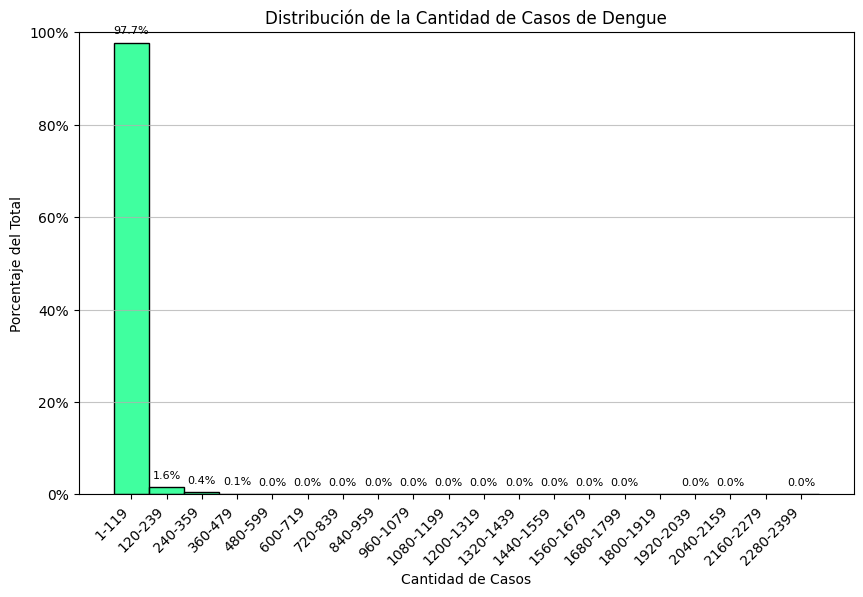

In [35]:
# Importamos librerías necesarias para graficar
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick # Importa el módulo ticker

# Obtenemos el máximo valor de 'cantidad'
max_cantidad = df['cantidad'].max()

# Definimos rangos de interés para el histograma: El primero de 1-119 casos, y los siguientes en rangos de 120
# comienzo del primer rango
bins_custom = [1]
# Fin del primer rango (1-119 implica que el rango es de 120)
bins_custom.append(120)

# Agregar los siguientes rangos hasta alcanzar la max_cantidad
current_edge = 120
while current_edge <= max_cantidad: # Asegura que el último sea al menos max_cantidad
    current_edge += 120
    bins_custom.append(current_edge)

plt.figure(figsize=(10, 6))
# Usar los rangos establecidos y color elegido
ax = sns.histplot(df['cantidad'], bins=bins_custom, stat='proportion', kde=False, color='springgreen')
plt.title('Distribución de la Cantidad de Casos de Dengue')
plt.xlabel('Cantidad de Casos')
plt.ylabel('Porcentaje del Total')
plt.grid(axis='y', alpha=0.75)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0)) # Formatear como porcentaje, valor máximo 1.0
plt.ylim(0, 1) # Establecer límite del eje y de 0 a 1 para stat='proportion', que corresponde al 0-100%

new_xticks = []
new_xticklabels = []

# Generar etiquetas
for p in ax.patches:
    lower_bound = p.get_x()
    upper_bound = p.get_x() + p.get_width()

    # Calcular el punto medio
    new_xticks.append(lower_bound + p.get_width() / 2)

    # Establecer la etiqueta como la queremos "lower - (upper-1)" (e.g., 1-119, 120-239)
    new_xticklabels.append(f'{int(lower_bound)}-{int(upper_bound - 1)}')

ax.set_xticks(new_xticks)
ax.set_xticklabels(new_xticklabels, rotation=45, ha='right')

# Añadir porcentajes exactos sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Solo etiquetar barras que tengan una altura > 0
        ax.annotate(f'{height*100:.1f}%',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=8)
output_path_drive = '/content/drive/MyDrive/UTN_FundamentosDatos/TrabajoFinal/distribucion_casos_dengue.png'
plt.savefig(output_path_drive, bbox_inches='tight')
print(f"Gráfico guardado como 'distribucion_casos_dengue.png'")
plt.show()

Vemos que el casi el 98% de los datos corresponden al rango entre 1 y 119 casos por semana epidemiológica en un departamento provincial de un año específico.

Graficamos un histograma eliminando este rango de casos para ver en detalle qué ocurre en las frecuencias más bajas de cantidad de casos (mayor cantidad de casos).

#### Distribución de Casos de Dengue: Detalle de registros con cantidad de casos mayor a 119

Para ver en detalle qué ocurre en el 2.3% de los registros con una cantidad más alta de casos, genero un histograma de aquellas entradas cuya `cantidad` sea superior 119.

Gráfico guardado como 'distribucion_casos_dengue_detalle.png'


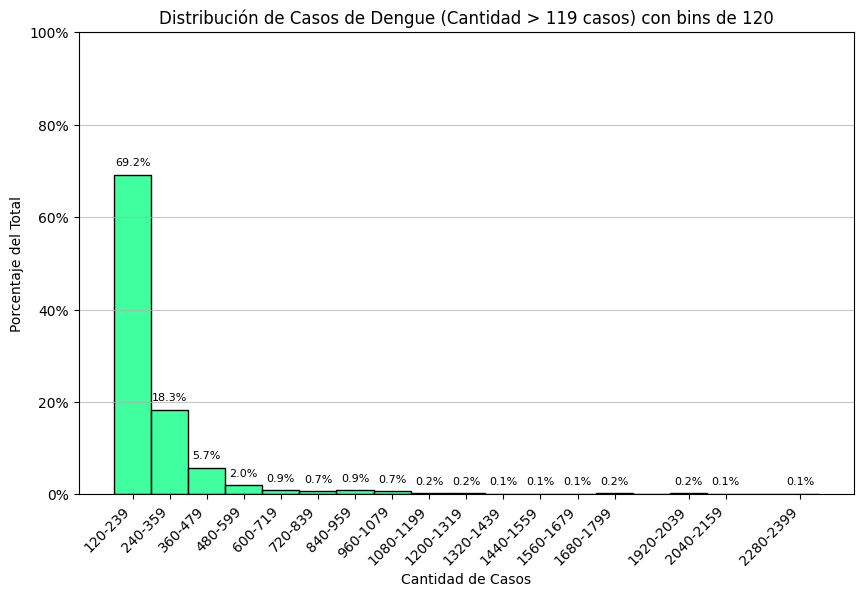

In [36]:
# Librería para operaciones matemáticas
import math

# Establecer el umbral para que los bins empiecen en 120
umbral_casos = 119 # Filtra para cantidad > 119, es decir, a partir de 120

# Filtrar el DataFrame para incluir solo registros con cantidad > umbral_casos
df_filtered_high_cases = df[df['cantidad'] > umbral_casos].copy() # Usar .copy() para evitar SettingWithCopyWarning

# Calcular el rango de la cantidad filtrada
min_val = df_filtered_high_cases['cantidad'].min()
max_val = df_filtered_high_cases['cantidad'].max()

bin_width = 120
# Generar los bordes de los bins. Empezar en 120 y avanzar en incrementos de 120.
# Asegurarse de que el último bin cubra el valor máximo.
bins = list(range(120, max_val + bin_width, bin_width))

plt.figure(figsize=(10, 6))
ax = sns.histplot(df_filtered_high_cases['cantidad'], bins=bins, stat='proportion', kde=False, color='springgreen')
plt.title(f'Distribución de Casos de Dengue (Cantidad > {umbral_casos} casos) con bins de {bin_width}') # Actualizar título
plt.xlabel('Cantidad de Casos')
plt.ylabel('Porcentaje del Total')
plt.grid(axis='y', alpha=0.75)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.ylim(0, 1) # Aseguramos que el eje Y vaya de 0 a 1 (100%)

new_xticks = []
new_xticklabels = []

# Obtener los bordes de los rangos reales creados por histplot
# y formatear las etiquetas
for p in ax.patches:
    lower_bound = p.get_x()
    upper_bound = p.get_x() + p.get_width()
    # Verificar si este rango realmente tiene datos
    if p.get_height() > 0:
        new_xticks.append(lower_bound + p.get_width() / 2)
        new_xticklabels.append(f'{int(lower_bound)}-{int(upper_bound - 1)}')

ax.set_xticks(new_xticks)
ax.set_xticklabels(new_xticklabels, rotation=45, ha='right')

# Añadir porcentajes exactos sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Solo etiquetar barras que tengan una altura > 0
        ax.annotate(f'{height*100:.1f}%',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=8)
output_path_drive = '/content/drive/MyDrive/UTN_FundamentosDatos/TrabajoFinal/distribucion_casos_dengue_detalle.png.png'
plt.savefig(output_path_drive, bbox_inches='tight')
print(f"Gráfico guardado como 'distribucion_casos_dengue_detalle.png'")
plt.show()


De los registros mayores a 119 en cantidad de casos, el 69.2% se encuentra en la categoría siguiente (120 a 239 casos). Esto se cooresponde a lo esperado para este tipo de datos epidemiológicos, donde la frecuencia disminuye a medida que aumenta la cantidad de casos. Sin embargo, los los valores más altos no son casos atípicos. El 0.4% de los registros con cantidad de casos mayores a 1920, representan aproximadamente 154 registros.

### e. **Búsqueda de registros duplicados**

Por último, verificamos si hay registros duplicados en la base de datos.

In [16]:
# Identificar y contar los registros duplicados
duplicated_rows = df.duplicated().sum()

# Imprimir el resultado
print(f"Número de registros duplicados en la base de datos: {duplicated_rows}")

# Opcional: Mostrar los registros duplicados si existen
if duplicated_rows > 0:
    print("\nRegistros duplicados (todas las columnas deben ser iguales):")
    display(df[df.duplicated()])
else:
    print("\nNo se encontraron registros duplicados.")

Número de registros duplicados en la base de datos: 0

No se encontraron registros duplicados.


No hay registros idénticos en la base de datos.

## 3. **Análisis de la cantidad y prevalencia de dengue**

### **Evolución de los casos de dengue a lo largo de las semanas epidemiológicas de 2024, 2025 y 2026 (Pregunta 1)**
Agrupamos los datos por año y semana epidemiológica y sumamos la cantidad de casos. Luego, creamos un gráfico de líneas para visualizar la evolución temporal.

Gráfico guardado como 'distribucion_temporal_dengue.png'


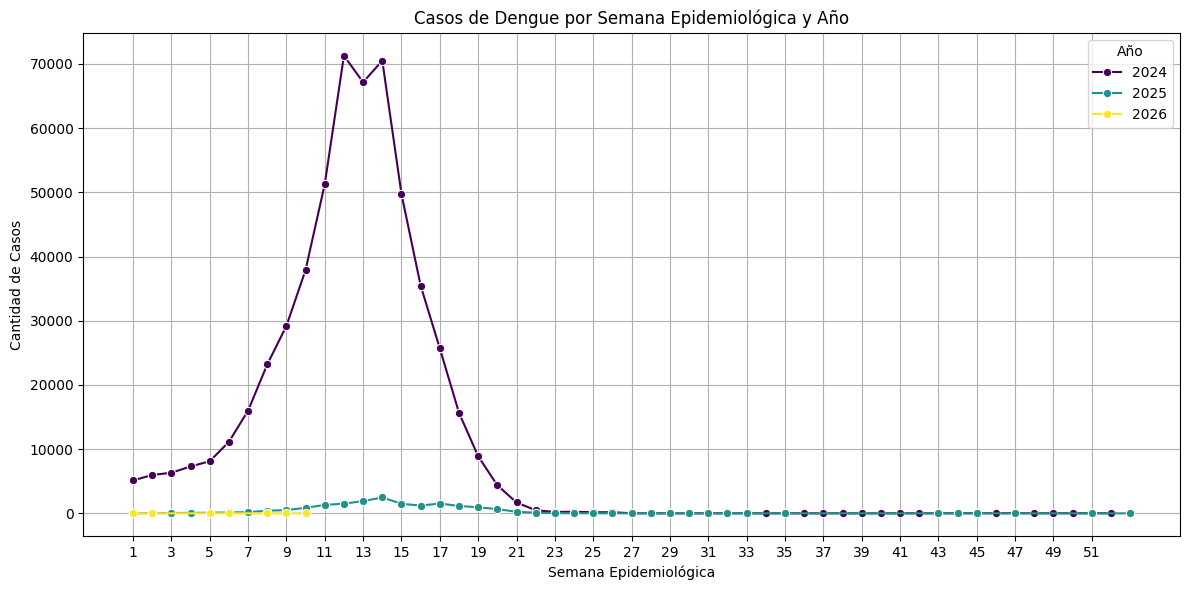

In [46]:
# Agrupar por año y semana epidemiológica y sumar la cantidad de casos
df_semana = df.groupby(['anio_min', 'sepi_min'])['cantidad'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_semana, x='sepi_min', y='cantidad', hue='anio_min', marker='o', palette='viridis')
plt.title('Casos de Dengue por Semana Epidemiológica y Año')
plt.xlabel('Semana Epidemiológica')
plt.ylabel('Cantidad de Casos')
plt.xticks(range(1, 53, 2)) # Mostrar cada 2 semanas para mayor claridad
plt.grid(True)
plt.legend(title='Año')
plt.tight_layout()


output_path_drive = '/content/drive/MyDrive/UTN_FundamentosDatos/TrabajoFinal/distribucion_temporal_dengue.png'
plt.savefig(output_path_drive, bbox_inches='tight')
print(f"Gráfico guardado como 'distribucion_temporal_dengue.png'")
plt.show()

El pico de casos ocurre para los años de 2024 y 2025 entre las semanas epidemiológicas 12 y 14.

Según la información registrada hasta el momento de 2026 (semana epidemiológica 10) aún no hemos entrado a la etapa de aumento de los casos de dengue.

Hay una diferencia muy significativa entre los registros de 2024 en comparación con 2025 y 2026. Esto no necesariamente se debe a una disminución de los casos de dengue en 2025 y 2026, sino que puede deberse a otros factores ajenos a los ciclos epidemiológicos, como la imposibilidad de siquiera generar los registros durante el año 2025 y 2026. Por ejemplo, por falta de recursos monetarios o humanos.

De manera que, con respecto a la pregunta número 1), sólo podemos indicar que la sumatoria de casos de los tres años mantiene el patrón de riesgo a un aumento de casos entre las semanas 5 y la 21 del año (evidenciada mayoritariamente por los casos de 2024).

**Dada a la mayor cantidad de registros de 2024, y bajo la suposición que en 2025 y 2026 los registros son insuficientes y por ende no representativos, para las preguntas 2) y 3) trabajaremos solo con los datos de 2024.**


### **Cantidad de casos por grupo etario (Pregunta 2)**

Para responder a cuál grupo etario es más propenso a contraer dengue (pregunta 2), compararemos los casos de los distintos grupos etarios a lo largo de las semanas epidemiológicas sólo de 2024.

Graficaremos solamente las semanas epidemiológicas 1 a 23 para una mejor visualización.

Gráfico guardado como 'distribucion_temporal_dengue_grupo-etario.png.png'


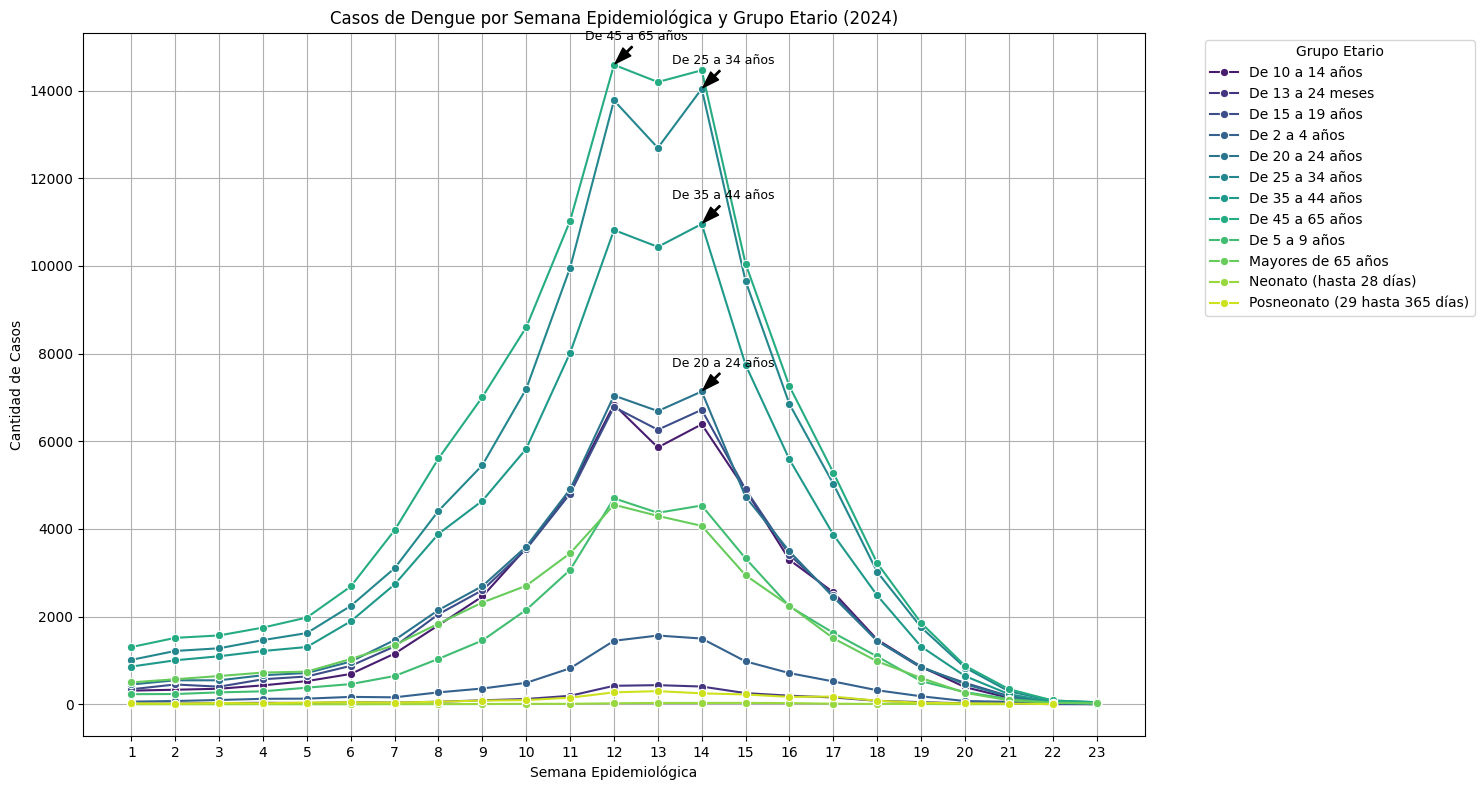

In [47]:
# Filtrar el DataFrame para incluir solo los registros del año 2024
df_2024 = df[df['anio_min'] == 2024]

# Restringir a semanas epidemiológicas desde la 1 hasta las 23
df_2024_filtered = df_2024[(df_2024['sepi_min'] >= 1) & (df_2024['sepi_min'] <= 23)]

# Agrupar por semana epidemiológica y grupo etario y sumar la cantidad de casos
df_grupo_etario_semana = df_2024_filtered.groupby(['sepi_min', 'grupo_etario'])['cantidad'].sum().reset_index()

plt.figure(figsize=(15, 8))
ax = sns.lineplot(data=df_grupo_etario_semana, x='sepi_min', y='cantidad', hue='grupo_etario', marker='o', palette='viridis')
plt.title('Casos de Dengue por Semana Epidemiológica y Grupo Etario (2024)')
plt.xlabel('Semana Epidemiológica')
plt.ylabel('Cantidad de Casos')
plt.xticks(range(1, 24, 1)) # Mostrar cada semana para mayor claridad en el rango reducido
plt.grid(True)
plt.legend(title='Grupo Etario', bbox_to_anchor=(1.05, 1), loc='upper left') # Mover la leyenda para evitar superposición

# 1. Identificar el máximo de casos para cada grupo etario
max_cases_per_group = df_grupo_etario_semana.groupby('grupo_etario')['cantidad'].max().reset_index()

# 2. Obtener los nombres de los 4 grupos etarios con el mayor número máximo de casos
top_4_group_names = max_cases_per_group.nlargest(4, 'cantidad')['grupo_etario'].tolist()

# 3. Para cada uno de estos 4 grupos, encontrar el punto (sepi_min, cantidad) donde alcanzan su máximo
peak_points_to_annotate = pd.DataFrame()
for group_name in top_4_group_names:
    group_data = df_grupo_etario_semana[df_grupo_etario_semana['grupo_etario'] == group_name]
    peak_row = group_data.loc[group_data['cantidad'].idxmax()]
    peak_points_to_annotate = pd.concat([peak_points_to_annotate, peak_row.to_frame().T], ignore_index=True)

# 4. Añadir etiquetas a estos 4 puntos de pico
for index, row in peak_points_to_annotate.iterrows():
    ax.annotate(
        f"{row['grupo_etario']}",
        xy=(row['sepi_min'], row['cantidad']),
        xytext=(row['sepi_min'] + 0.5, row['cantidad'] + 500), # Ajustar la posición del texto
        arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
        ha='center', va='bottom', fontsize=9, color='black'
    )
plt.tight_layout()

output_path_drive = '/content/drive/MyDrive/UTN_FundamentosDatos/TrabajoFinal/distribucion_temporal_dengue_grupo-etario.png'
plt.savefig(output_path_drive, bbox_inches='tight')
print(f"Gráfico guardado como 'distribucion_temporal_dengue_grupo-etario.png.png'")
plt.show()

De acuerdo a la información de 2024, los grupos etarios de riesgo son aquellos comprendidos entre 25 y 65 años. En particular, el rango etario con el máximo de casos es el de 45 a 65 años.
Incluso comienzan el año 2024 (semana 1) con más cantidad de casos que el resto de los rangos etarios. Puede deberse a que contenida entre los 25 y 65 años está la gran parte de la población trabajadora, lo que implica una movilización de las personas a lo largo del territorio, aumentando el área de contagio en presencia del vector.

Son llamativos los picos en forma de M, con una disminución del registro de casos en la semana 13 para los rangos etarios con mayor frecuencia de casos. Se deberían investigar factores como capacidad de registro, condiciones ambientales y presencia del vector en esa semana para inferir alguna causa.

Es esperable quese registren menos cantidad de casos en los rangos de los extremos de edades, debido a que permanecen en zonas más restringidas que los rangos etarios intermedios.

### **Análisis de cantidad de casos de dengue por provincia (Pregunta 3)**

Para responder la pregunta 3) comenzamos identificando las provincias con mayor cantidad de casos totales.

In [19]:
# Agrupar el DataFrame principal por provincia_residencia y sumar la cantidad de casos
df_casos_por_provincia = df.groupby('provincia_residencia')['cantidad'].sum().reset_index()
df_casos_por_provincia = df_casos_por_provincia.rename(columns={'provincia_residencia': 'Provincia', 'cantidad': 'TotalCasos'})

# Ordenar por el total de casos de forma descendente y mostrar el top 10
top_10_provincias = df_casos_por_provincia.sort_values(by='TotalCasos', ascending=False).head(10)

print("Top 10 de provincias con mayor cantidad de casos:")
display(top_10_provincias)

Top 10 de provincias con mayor cantidad de casos:


,Provincia,TotalCasos
0,Buenos Aires,110013
6,Córdoba,107686
23,Tucumán,84366
20,Santa Fe,71377
16,Salta,24136
1,CABA,23931
3,Chaco,21428
7,Entre Ríos,19521
21,Santiago del Estero,18812
13,Misiones,18286


Como es de esperar, las provincias con mayor población y ciudades grandes, son las que presentan la mayor cantidad de casos, como Buenos Aires y Córdoba. Contrario a lo esperado debido a la densidad de población, si bien CABA está dentro de las más afectadas, se encuentra en una posición relativa más baja, pero comparables a provincias más grandes y menos densamente pobladas.

Para entender la distribución temporal de los casos de cada provincia y si hay patrones temporales distintivos para cada provincia, también graficamos cantidad de casos vs. semana epidemiológica. Acotamos el rango de semanas desde la 1 a la 23 para una mejor visualización.





Gráfico guardado como 'distribucion_temporal_dengue_provincia.png'


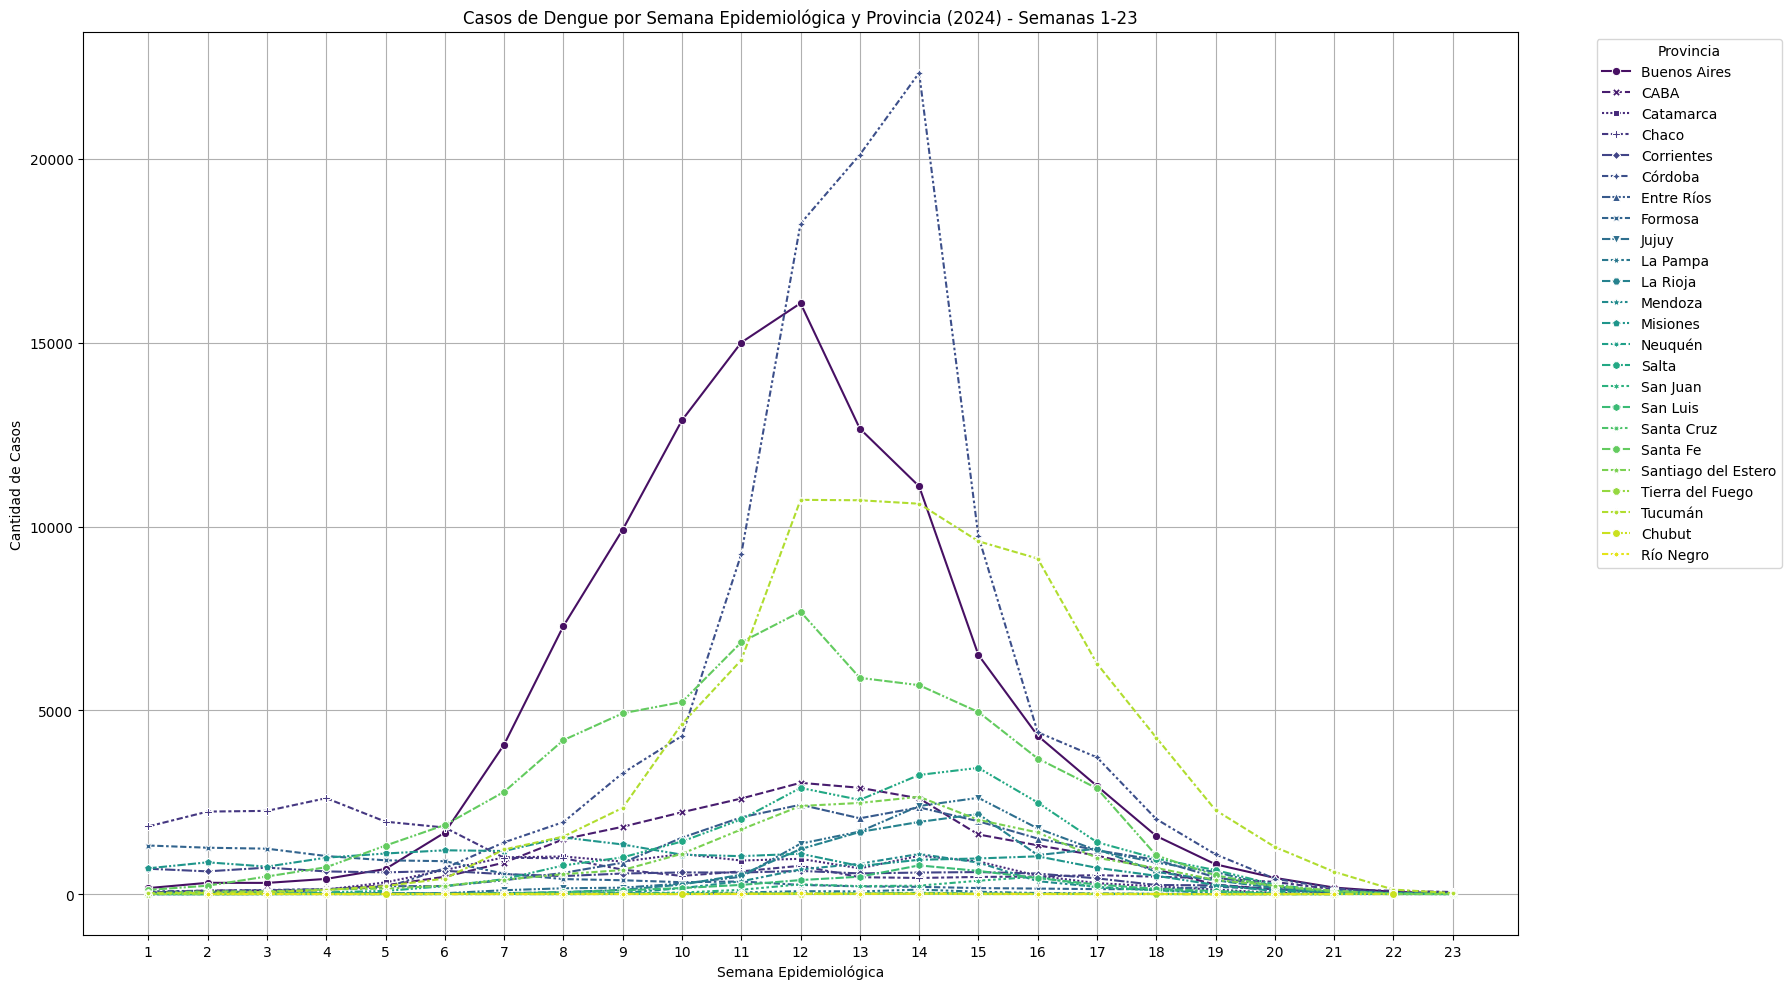

In [48]:
# Usando el data set de 2024, agrupamos por semana epidemiológica y provincia, y sumamos la cantidad de casos
df_provincia_semana_2024 = df_2024.groupby(['sepi_min', 'provincia_residencia'])['cantidad'].sum().reset_index()

# Filtrar para las semanas epidemiológicas 1 a 23
df_provincia_semana_2024_filtered = df_provincia_semana_2024[(df_provincia_semana_2024['sepi_min'] >= 1) & (df_provincia_semana_2024['sepi_min'] <= 23)]

plt.figure(figsize=(18, 10))
sns.lineplot(data=df_provincia_semana_2024_filtered, x='sepi_min', y='cantidad', hue='provincia_residencia', style='provincia_residencia', markers=True, errorbar=None, palette='viridis')

plt.title('Casos de Dengue por Semana Epidemiológica y Provincia (2024) - Semanas 1-23')
plt.xlabel('Semana Epidemiológica')
plt.ylabel('Cantidad de Casos')
plt.xticks(range(1, 24, 1)) # Mostrar cada semana para mayor claridad en el rango reducido
plt.grid(True)
plt.legend(title='Provincia', bbox_to_anchor=(1.05, 1), loc='upper left') # Mover la leyenda para evitar superposición
plt.tight_layout()

output_path_drive = '/content/drive/MyDrive/UTN_FundamentosDatos/TrabajoFinal/distribucion_temporal_dengue_provincia.png'
plt.savefig(output_path_drive, bbox_inches='tight')
print(f"Gráfico guardado como 'distribucion_temporal_dengue_provincia.png'")
plt.show()

En este gráfico observamos:

- La provincia de Córdoba presenta el pico más alto de casos, como hemos visto anteriormente, con su máximo en la semana 14 y acotado aproximadamente entre las semanas 12 y 14.

- Buenos Aires presenta un pico máximo de casos más tempranamente, en la semana 12, y se extiende entre la semana 9 y 14, un período más largo de tiempo que para Córdoba.

- Tucumán registra el máximo de casos durante tres semanas seguidas (12 a 14), y la disminución de casos es más lenta, manteniendo un número de casos altos hasa la semana 16.

- Curiosamente, si bien la provincia de Chaco registra un número relativamente bajo en comparación a las provincias principales, su máximo se registra muy temprano, en la semana 4. También comienza el año (semana 1) con la mayor cantidad relativa de casos en comparación a las restantes provincias. Esto puede deberse a las condiciones ambientales específicas del Chaco, donde entre octubre y marzo se registra la mayor cantidad de precipitaciones, necesarias para el desarrollo del mosquito dado que su estadío larvario se desarrolla en el agua.


Para responder a la Subpregunta planteada al inicio, identificamos los departamentos de la provincia de Buenos Aires con mayor cantidad de casos:

Top 10 de departamentos de la Provincia de Buenos Aires con mayor cantidad de casos:


,departamento_residencia,cantidad
65,La Matanza,10873
62,José C. Paz,9029
67,Lanús,6625
75,Lomas de Zamora,6573
86,Moreno,6382
100,Quilmes,5996
114,San Miguel,5945
55,General San Martín,4742
40,Florencio Varela,4280
7,Avellaneda,4096


Gráfico guardado como 'dengue_top10_BsAs.png'


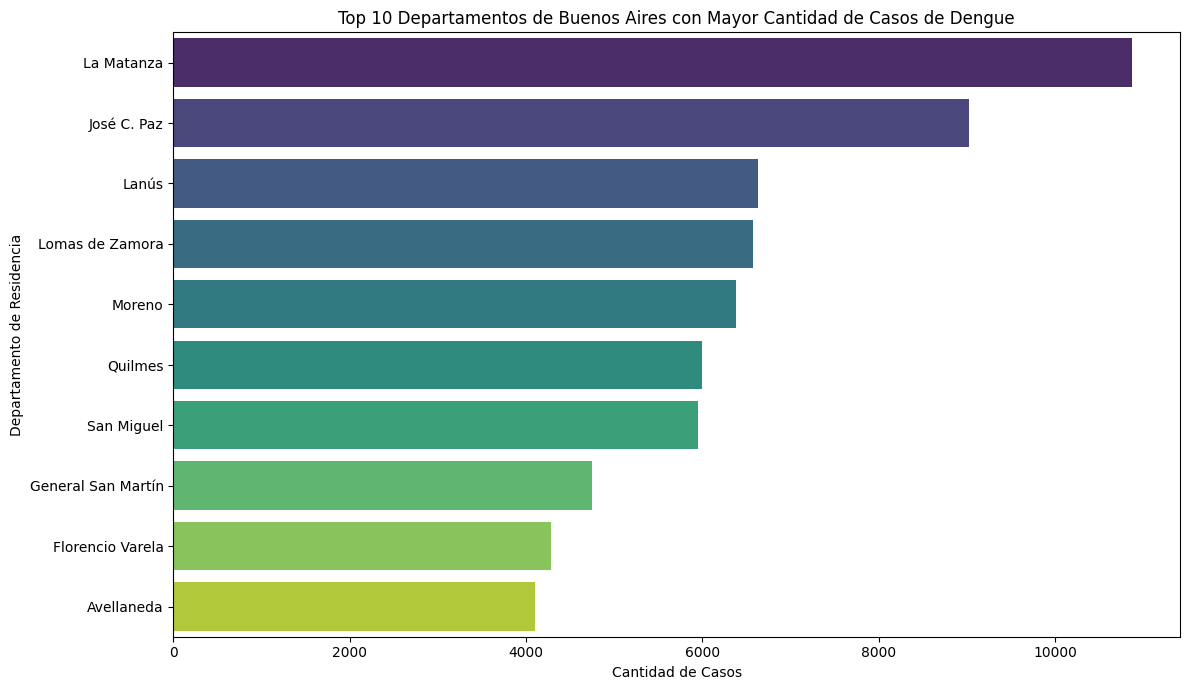

In [41]:
# Filtrar el DataFrame para la provincia de Buenos Aires
df_buenos_aires = df[df['provincia_residencia'] == 'Buenos Aires']

# Agrupar por departamento y sumar la cantidad de casos
df_casos_por_departamento_ba = df_buenos_aires.groupby('departamento_residencia')['cantidad'].sum().reset_index()

# Ordenar por cantidad de casos de forma descendente y obtener el top 10
top_10_departamentos_ba = df_casos_por_departamento_ba.sort_values(by='cantidad', ascending=False).head(10)

print("Top 10 de departamentos de la Provincia de Buenos Aires con mayor cantidad de casos:")
display(top_10_departamentos_ba)

# Crear un gráfico de barras para visualizar la cantidad de casos por departamento
plt.figure(figsize=(12, 7))
sns.barplot(x='cantidad', y='departamento_residencia', data=top_10_departamentos_ba, palette='viridis', hue='departamento_residencia', legend=False)
plt.title('Top 10 Departamentos de Buenos Aires con Mayor Cantidad de Casos de Dengue')
plt.xlabel('Cantidad de Casos')
plt.ylabel('Departamento de Residencia')
plt.tight_layout()


output_path_drive = '/content/drive/MyDrive/UTN_FundamentosDatos/TrabajoFinal/dengue_top10_BsAs.png'
plt.savefig(output_path_drive, bbox_inches='tight')
print(f"Gráfico guardado como 'dengue_top10_BsAs.png'")
plt.show()


Los departamentos de La Matanza y José C. Paz encabezan la mayoría de casos, más de 9000, en comparación con el departamento siguiente, con menos de 7000 casos registrados.

Graficamos cantidad de casos vs. semana epidemiológica de la 1 a la 23 distinguiendo por departamentos de la provincia de Buenos Aires.

Gráfico guardado como 'distribucion_temporal_dengue_departamentos-BsAs.png'


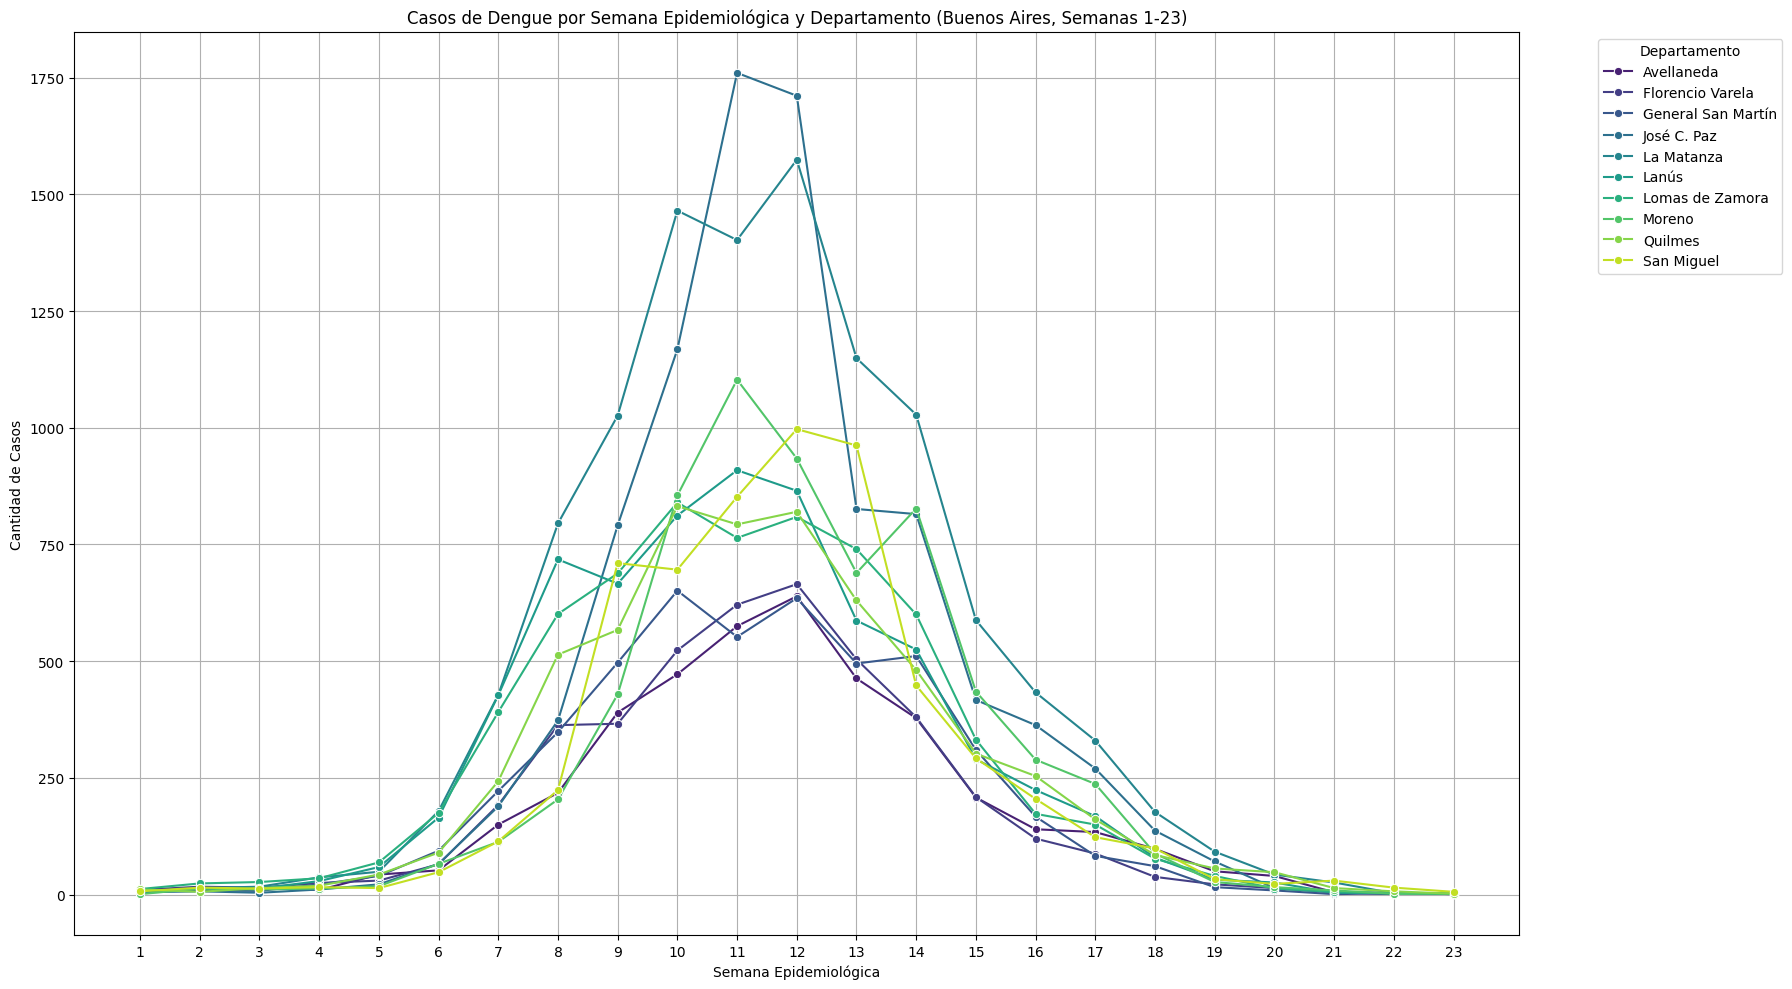

In [49]:
# Filtrar el DataFrame de Buenos Aires para las semanas 1 a 23
df_buenos_aires_filtered_weeks = df_buenos_aires[
    (df_buenos_aires['sepi_min'] >= 1) & (df_buenos_aires['sepi_min'] <= 23)
].copy()

# Obtener la lista de los top 10 departamentos de Buenos Aires
top_10_departamentos_list = top_10_departamentos_ba['departamento_residencia'].tolist()

# Filtrar el DataFrame para incluir solo los top 10 departamentos
df_buenos_aires_top10_depto_semana = df_buenos_aires_filtered_weeks[
    df_buenos_aires_filtered_weeks['departamento_residencia'].isin(top_10_departamentos_list)
]

# Agrupar por semana epidemiológica y departamento, y sumar la cantidad de casos
df_buenos_aires_plot = df_buenos_aires_top10_depto_semana.groupby(['sepi_min', 'departamento_residencia'])['cantidad'].sum().reset_index()

plt.figure(figsize=(18, 10))
sns.lineplot(data=df_buenos_aires_plot, x='sepi_min', y='cantidad', hue='departamento_residencia', marker='o', palette='viridis')

plt.title('Casos de Dengue por Semana Epidemiológica y Departamento (Buenos Aires, Semanas 1-23)')
plt.xlabel('Semana Epidemiológica')
plt.ylabel('Cantidad de Casos')
plt.xticks(range(1, 24, 1)) # Mostrar cada semana para mayor claridad en el rango reducido
plt.grid(True)
plt.legend(title='Departamento', bbox_to_anchor=(1.05, 1), loc='upper left') # Mover la leyenda para evitar superposición
plt.tight_layout()


output_path_drive = '/content/drive/MyDrive/UTN_FundamentosDatos/TrabajoFinal/distribucion_temporal_dengue_departamentos-BsAs.png'
plt.savefig(output_path_drive, bbox_inches='tight')
print(f"Gráfico guardado como 'distribucion_temporal_dengue_departamentos-BsAs.png'")
plt.show()

Si bien La Matanza presenta una mayor cantidad de casos que en José C. Paz, este gráfico muestra que el máximo de casos es mayor (aproximadamente 1750) y más acotado para este último, ocurriendo en las semanas 11 y 12, disminuyendo drásticamente para la semana 13. En cambio, si bien en La Matanza el máximo es menor, la cantidad de casos se mantiene por encima de las 1200 a lo largo de tres semanas consecutivas (10 a 12), y la disminución de casos es más lenta.

Para el resto de los departamentos, los máximos de casos están contenidos entre las semanas 10 y 12

## **Conclusiones**

Se requieren reforzar medidas de prevención antes de las semana 1 para la mayoría de las provincias excepto Chaco, donde debe comenzar antes (necesitaríamos la información de finales de año 2023 para ser más precisos).

Además, sería importante mejorar las medidas de prevención en los departamentos de La Matanza y José C. Paz, y hacer estudios de causalidad.

Podrían implementarse medidas de vacunación para los grupos etarios ente 25 y 65 años, comenzando por el rango de 45 a 65 años.

Teniendo en cuenta que en las zonas más pobladas siempre habrá mayor cantidad de casos, una mejor opción sería analizar la prevalencia de dengue por provincia (y departamentos). La prevalencia de una enfermedad mide la proporción total de personas que padecen una enfermedad en una población específica y un momento determinado (casos nuevos + antiguos), indicando la carga de la enfermedad. Pero para esto, necesitaríamos incorporar la información de población de cada una de las provincias. Puede implementarse en análisis futuros.


Guardamos el conjunto de datos de 2024 en un .csv para crear un dashboard en PowerBI:

In [43]:
# Guardar el DataFrame 'df_2024' en un archivo .csv en la misma carpeta de Drive
output_path = "/content/drive/MyDrive/UTN_FundamentosDatos/TrabajoFinal/dengue_data_procesada_2024.csv"
df_2024.to_csv(output_path, index=False, encoding='utf-8')

print(f"El conjunto de datos ha sido guardado exitosamente en: {output_path}")

# Generar el archivo requirements.txt
requirements_content = [
    "pandas",
    "matplotlib",
    "seaborn"
]

requirements_path = "/content/drive/MyDrive/UTN_FundamentosDatos/TrabajoFinal/requirements.txt"
with open(requirements_path, "w") as f:
    for req in requirements_content:
        f.write(req + "\n")

print(f"El archivo requirements.txt ha sido generado exitosamente en: {requirements_path}")

El conjunto de datos ha sido guardado exitosamente en: /content/drive/MyDrive/UTN_FundamentosDatos/TrabajoFinal/dengue_data_procesada_2024.csv
El archivo requirements.txt ha sido generado exitosamente en: /content/drive/MyDrive/UTN_FundamentosDatos/TrabajoFinal/requirements.txt
